# The Artificial Neuron

## Begin with a small decision

Imagine a greenhouse with two sensors. One reports how dry the soil is. The other reports how warm the air is. We want a little controller to combine those readings into a response.

Dry soil should encourage watering. Warm air might add some encouragement, but perhaps not as much. Looking at just one sensor would ignore part of the information we have.

We could write a separate rule for every possible pair of readings. A simpler starting point is to give each reading an influence, add the contributions, and decide what to do with the total.

That small calculation is the idea behind an **artificial neuron**. It combines input values using adjustable numbers and then applies a response rule.

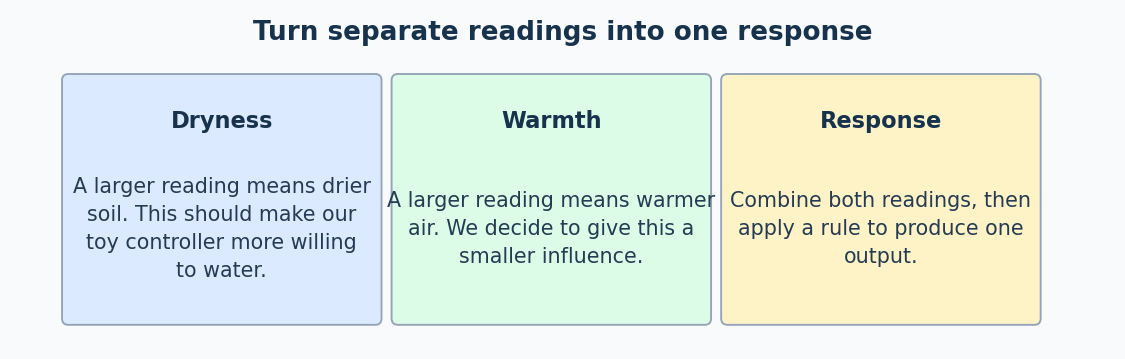

We will follow one example from start to finish. The sensor scales and settings are invented to make the arithmetic clear; they are not validated instructions for watering plants. The [code companion](02_The_Artificial_Neuron.ipynb) performs the same calculations in PyTorch.

## Start with the problem this lesson solves

Imagine deciding whether a greenhouse needs watering using normalized dryness and warmth readings. Dryness should matter more than warmth, and weak evidence should not automatically trigger watering. A neuron expresses these choices as adjustable weights and a bias.

The inputs are measurements; the weights and bias are stored model parameters. A forward calculation uses the parameters to make a prediction. Learning, introduced later, changes the parameters using examples of correct decisions.

## Follow every contribution through one neuron

Use input $x=[0.8,0.4]$, weights $w=[2,1]$, and bias $b=-1.5$. These are hand-chosen teaching values, not a fitted watering policy.

1. **Weight dryness:** $0.8\times2=1.6$. A change of $0.1$ in dryness changes the score by $0.2$.
2. **Weight warmth:** $0.4\times1=0.4$. A change of $0.1$ in warmth changes the score by $0.1$.
3. **Combine evidence:** $1.6+0.4=2.0$.
4. **Apply the reference level:** $z=2.0-1.5=0.5$. The bias means the weighted evidence must exceed $1.5$ before the score becomes positive.
5. **Convert the score:** a strict step rule gives one because $0.5>0$. Sigmoid instead gives

$$p=\frac{1}{1+e^{-0.5}}=\frac{1}{1+0.606531}\approx0.622459.$$

A threshold of $p>0.5$ makes the same decision as $z>0$. The value $0.622459$ is a model probability only under an appropriate probabilistic interpretation; hand-setting weights does not make it a calibrated 62% real-world chance.

For a less dry greenhouse, $x=[0.2,0.4]$, the same calculation is $z=0.2(2)+0.4(1)-1.5=-0.7$, then $p\approx0.331812$. The parameters have not changed; only the measurements have changed.

**How could this neuron learn?** Suppose the first example's known target is watering, $y=1$. Its binary cross-entropy is $-\ln(0.622459)\approx0.474077$. For this loss with sigmoid, the score gradient is $p-y=-0.377541$. The weight gradients are that number times each input: $[-0.302033,-0.151016]$. The bias gradient is $-0.377541$.

With SGD rate $0.1$, subtract $0.1$ times each gradient:

$$w'\approx[2.030203,1.015102],\qquad b'\approx-1.462246.$$

The updated score is approximately $0.8(2.030203)+0.4(1.015102)-1.462246=0.567957$, and its sigmoid is about $0.6383$. The neuron has moved its response toward the known target. This added one-step explanation is illustrative; the companion's original experiments inspect fixed parameters.

## Why a neuron helps, and where it stops helping

Multiplication controls influence, addition combines evidence, bias controls the reference level, and an activation gives the response its intended form. Learning replaces our hand-picked choices with values supported by training examples. The neuron never understands “dryness” as a word; feature order and numerical meaning come from us.

A single threshold neuron creates one straight boundary in two dimensions. It can combine simple evidence, but cannot represent every decision rule—for example, XOR. Multiple nonlinear units are needed when the useful decision cannot be expressed by one weighted sum.

## Give the readings names before writing an equation

Suppose both sensors report values between zero and one. For dryness, zero means very wet and one means very dry. For warmth, zero means cool and one means warm. These are fixed teaching scales, not temperatures in degrees.

Our current readings are:

| Reading | Symbol | Value | Plain meaning |
| --- | --- | --- | --- |
| Soil dryness | $x_1$ | 0.8 | Relatively dry soil |
| Air warmth | $x_2$ | 0.4 | A lower warmth reading |

The letter $x$ stands for input. The small subscripts distinguish the two inputs; they do not tell us to multiply or square anything.

The computer only sees numbers. It does not know that dryness should matter more unless our calculation gives dryness a different influence. That is the job of a weight.

## Use weights to control each input’s influence

A **weight** is a multiplier attached to an input. If we multiply dryness by two and warmth by one, a small change in dryness has twice the direct effect on the score as the same numerical change in warmth.

Call those weights $w_1=2$ and $w_2=1$. First calculate each contribution separately:

| Input | Reading | Weight | Weighted contribution |
| --- | --- | --- | --- |
| Dryness | 0.8 | 2 | $0.8\times2=1.6$ |
| Warmth | 0.4 | 1 | $0.4\times1=0.4$ |

Now add the contributions: $1.6+0.4=2.0$. This is the **weighted sum**. The word “weighted” means we multiplied each input by its assigned weight before adding.

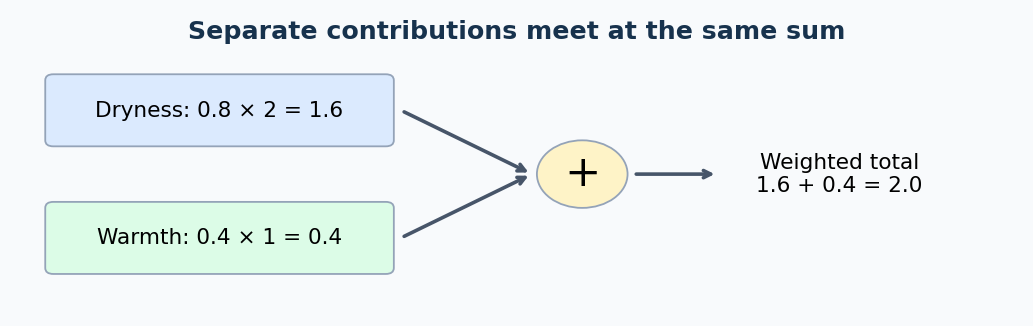

The branches in the diagram matter. Warmth is not calculated from dryness; the two contributions arrive independently and are then added.

For a small demonstration, increase only dryness from $0.8$ to $0.9$. Its contribution rises from $1.6$ to $1.8$, so the total rises by $0.2$. Increasing only warmth by $0.1$ would raise the total by $0.1$ instead.

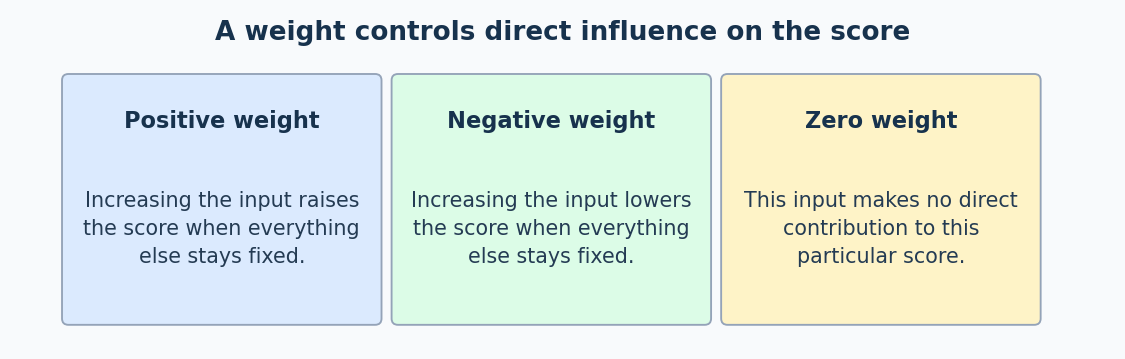

Weight magnitudes must be understood alongside the inputs’ units and ranges. A weight on a fraction cannot be compared directly with a weight on degrees Celsius. And a numerical influence inside this calculation is not automatically a causal effect in the real world.

## The total still needs a reference point

We have a total of two. But is two enough to produce a positive response? The weighted sum alone has not answered that.

Suppose our toy rule requires the total to exceed $1.5$. We can subtract that reference value and compare the result with zero:

$$2.0-1.5=0.5.$$

Adding an offset of $-1.5$ achieves the same thing. That offset is the **bias**, written as $b$. The resulting value is the **score**, written as $z$.

$$z=w_1x_1+w_2x_2+b.$$

| Symbol | Job in the calculation |
| --- | --- |
| $x_1,x_2$ | Supply the current readings |
| $w_1,w_2$ | Multiply those readings |
| $b$ | Add one shared offset |
| $z$ | Store the resulting score |

Substituting our actual numbers gives

$$z=2(0.8)+1(0.4)-1.5=0.5.$$

A bias is added **once per example**, after the input contributions are combined. It is not an extra input reading or an error term. In this setting, “bias” simply means an adjustable offset.

Without a bias, zero inputs always produce a zero score. With a bias, the neuron can shift that starting score. A negative bias does not have to remain negative; its value is a setting the model can learn.

## Separate what arrives from what the model stores

The readings change from one greenhouse to another. The weights and bias belong to the neuron and are reused for each new pair of readings.

These stored adjustable values are called **parameters**. Our neuron has three: two weights and one bias.

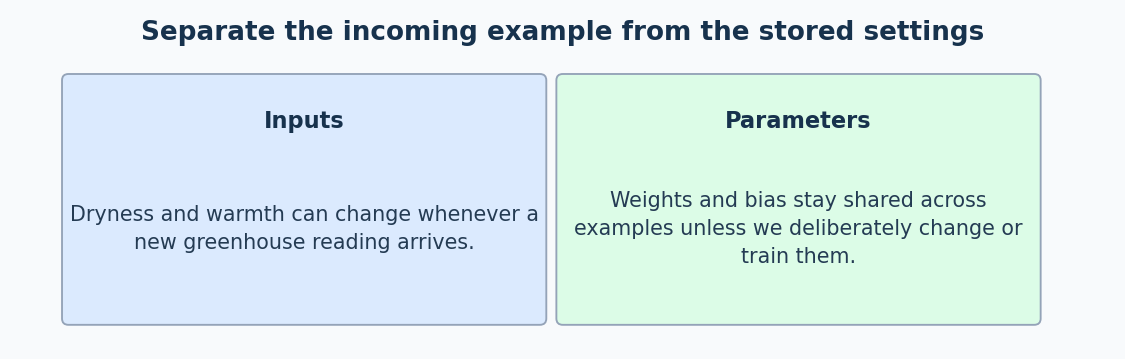

We chose the parameters ourselves here so every contribution is easy to follow. During training, a learning procedure can change them using data. The inputs do not become parameters merely because they appear in the equation.

For a neuron with more inputs, repeat the same operation: multiply each input by its weight, add the products, and add one bias. A compact way to write that is

$$z=\sum_{i=1}^{d}w_i x_i+b.$$

$d$ is the number of inputs. $i$ identifies one input at a time. The summation symbol $\sum$ means “add these terms.” A biased neuron with $d$ inputs therefore has $d+1$ parameters: one weight per input, plus one bias.

## Turn the score into the response we want

The score is $0.5$. We can keep that number, or apply another rule before passing it onward. That rule is called an **activation function**.

We write the response as $a=\phi(z)$. Here $a$ means output, and $\phi$ (“phi”) is simply a name for the activation function. The expression means “apply the chosen rule to the score.”

| Response rule | What it does | Output for score 0.5 |
| --- | --- | --- |
| Identity | Leave the score unchanged | 0.5 |
| Hard step | Return one if the score is positive, otherwise zero | 1 |
| ReLU | Keep positive scores; replace negative ones with zero | 0.5 |
| Sigmoid | Smoothly compress scores between zero and one | About 0.622 |

For our yes-or-no demonstration, use a strict step: the score must be greater than zero to return one. Exactly zero returns zero. That boundary convention is a choice; we use it consistently.

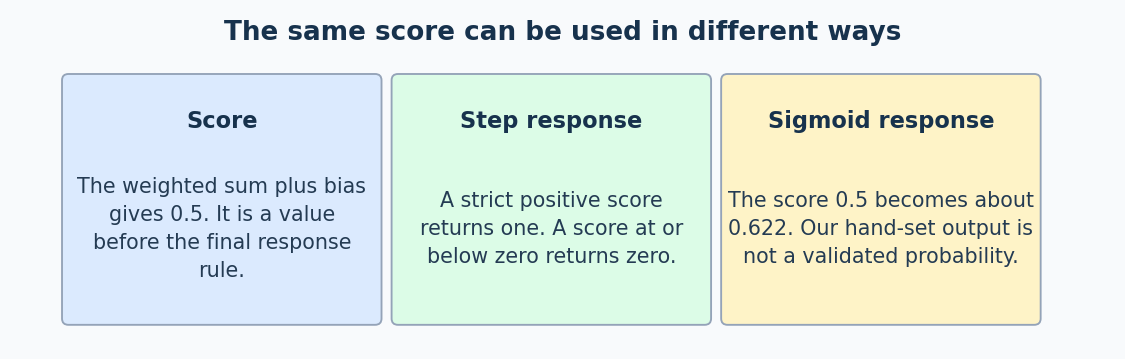

The activation choices in the table are alternatives. We are not applying every one in sequence. The full artificial neuron is the weighted sum, bias, and chosen activation together.

A hard-threshold neuron is often called a **perceptron**. It is a computational building block, not a realistic simulation of a biological nerve cell.

## See where the sigmoid number comes from

Sigmoid gives a gradual response instead of an immediate jump from zero to one. Its equation is

$$\sigma(z)=\frac{1}{1+e^{-z}}.$$

$\sigma$ names the sigmoid function. $z$ is the score we already calculated. $e\approx2.718$ is the base of the natural exponential; $e^{-z}$ is the exponential term in the denominator.

We can follow our score through the formula in small steps:

| Calculation | Result |
| --- | --- |
| Use score $z=0.5$ | Exponent is $-0.5$ |
| Calculate $e^{-0.5}$ | About 0.607 |
| Add one | About 1.607 |
| Divide one by that result | About 0.622 |

This output lies between zero and one, but our hand-set controller has not established a $62.2\%$ chance of anything. A probability estimate needs an appropriate classification task, training, and evaluation.

The hard step has a different limitation: away from its jump, small score changes leave the output unchanged. At the jump it has no ordinary derivative. That makes it unsuitable for ordinary gradient-based learning, which uses local sensitivities to guide parameter changes. Other activation functions provide different sensitivity patterns.

## Pass several examples through the same neuron

Keep the weights at $(2,1)$ and the bias at $-1.5$. Now change only the readings:

| Dryness | Warmth | Score $2x_1+x_2-1.5$ | Step response | Sigmoid response |
| --- | --- | --- | --- | --- |
| 0.8 | 0.4 | 0.5 | 1 | 0.622 |
| 0.2 | 0.4 | -0.7 | 0 | 0.332 |
| 0.5 | 0.5 | 0 | 0 | 0.500 |
| 0.9 | 0.9 | 1.2 | 1 | 0.769 |

For the second greenhouse, dryness contributes $2(0.2)=0.4$ and warmth contributes $0.4$. Adding the bias gives $0.4+0.4-1.5=-0.7$. The step returns zero, while sigmoid gives a smaller gradual response.

We have performed a **forward pass**: computing outputs from inputs using the current parameters. None of these calculations requires the parameters to change.

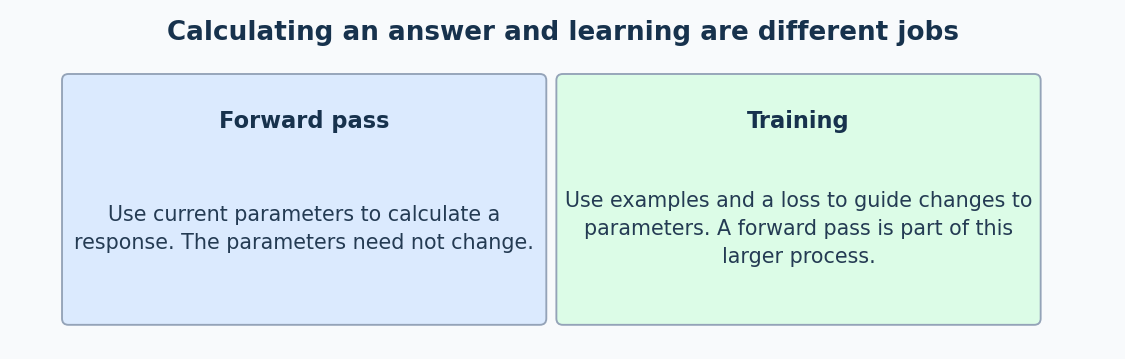

The companion uses fixed parameters and deliberately controlled changes. Its examples explain arithmetic; they are not a held-out performance evaluation of a trained watering system.

## Draw the decision to understand the bias

The step changes its answer at score zero. For our parameters, that boundary is

$$2x_1+x_2-1.5=0.$$

Rearranging gives $x_2=1.5-2x_1$, a straight line in the plane of the two readings. One side has positive scores; the other has nonpositive scores.

Keep the weights fixed and increase the bias from $-1.5$ to $-1.0$. Every score rises by $0.5$. The dividing line shifts parallel to itself, allowing more of the plotted region to receive a positive response.

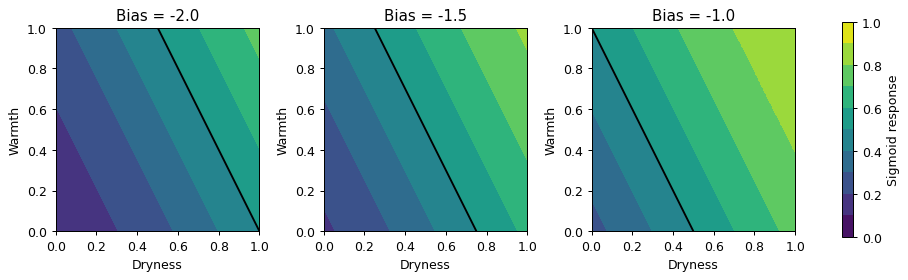

The colors show sigmoid responses, not measured watering probabilities. The black line is where the score is zero and sigmoid equals one half.

| Change | Direct effect |
| --- | --- |
| Increase one input | Score changes by that input's weight times the increase |
| Increase the bias | Every example's score shifts by the same amount |
| Change a weight | Affects that input's influence and can rotate the boundary |

Sigmoid changes the response scale, but thresholding it above one half still follows this same line. A nonlinear activation does not automatically give a single thresholded affine score a curved boundary.

## Organize several readings without changing the calculation

A **batch** groups examples so we can process them together. A **tensor** is an array of numbers, and its **shape** lists the lengths of its axes.

For our four sensor pairs, PyTorch uses:

| Quantity | Shape | How to read it |
| --- | --- | --- |
| Input $X$ | `(4, 2)` | Four examples, two readings each |
| Weight $W$ | `(1, 2)` | One output unit, two weights |
| Bias $b$ | `(1,)` | One offset for that unit |
| Scores $Z$ | `(4, 1)` | One score for every example |

The batch calculation is $Z=XW^T+b$. The superscript $T$ means transpose: exchange the weight matrix's rows and columns so matrix multiplication matches the input-feature axis. The bias is reused once for every row.

`nn.Linear(2, 1)` implements these weighted sums and bias additions. It does not include an activation. The companion applies the response function separately and compares the result with the hand calculation.

More rows mean more examples to process. They do not give this neuron more parameters; the same two weights and one bias are shared.

## Discover a limit of one threshold neuron

Now replace the sensor readings with binary switches: each is either off, represented by zero, or on, represented by one.

| Switches | AND: both on | OR: at least one on | XOR: exactly one on |
| --- | --- | --- | --- |
| $(0,0)$ | 0 | 0 | 0 |
| $(0,1)$ | 0 | 1 | 1 |
| $(1,0)$ | 0 | 1 | 1 |
| $(1,1)$ | 1 | 1 | 0 |

AND works with weights $(1,1)$ and bias $-1.5$: only the sum of two exceeds the cutoff. OR works with the same weights and bias $-0.5$: either active switch is enough.

XOR means **exclusive or**. The two positive cases occupy opposite corners. A single straight line cannot separate them from the negative corners.

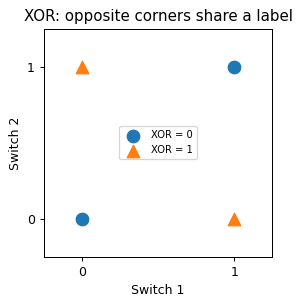

This is not simply a matter of finding better weights. We can show why no choice works for our affine score and strict step:

| Required case | What the score must satisfy |
| --- | --- |
| $(0,0)$ must return zero | $b\leq0$ |
| $(1,0)$ must return one | $w_1+b>0$ |
| $(0,1)$ must return one | $w_2+b>0$ |

Add the last two inequalities: $w_1+w_2+2b>0$. Subtract one bias to obtain $w_1+w_2+b>-b$. Since $b\leq0$, the right side is nonnegative. The score for $(1,1)$ must therefore be positive—but XOR requires zero there. The requirements contradict each other.

Additional features or several units with nonlinear processing can overcome this restriction. More training alone cannot remove it from a single affine score with this threshold rule.

## Understand what this small building block gives us

An artificial neuron gives us a reusable way to combine inputs, shift a score, and choose an output response. Its role depends on where we place it and what task we train it for.

| Use | Meaning of the output |
| --- | --- |
| Identity-output neuron for regression | A numerical estimate |
| Affine score with sigmoid and binary classification training | A class-probability estimate |
| Hidden neuron inside a larger network | An intermediate value used by other computations |

A hidden response need not be a class probability or a concept we can easily name. Nor does a larger weight by itself prove that a feature is more important: its units and the rest of the model matter.

The worked example shows exactly what the neuron computes. Useful real predictions require more than correct arithmetic: suitable inputs, an appropriate task, learned or justified parameters, and evaluation on relevant examples.